# 📚 Book Recommendation System

### Personalized Book Recommendation Using Machine Learning & Collaborative Filtering


## 🎯 Objective

The objective of this project is to develop a **personalized Book Recommendation System** that recommends relevant books to users based on historical user-rating patterns.

### Key Objectives

* Implement multiple book recommendation techniques.
* Analyze user-book rating data.
* Evaluate recommendation models using **Precision@10, Recall@10, F1@10, and Hit Rate@10**.
* Compare the performance of different recommendation approaches.
* Select a suitable final recommendation model.
* Generate personalized Top-N book recommendations.
* Develop an interactive **Streamlit application** for the final recommendation system.


## Project Overview

The **Book Recommendation System** is a machine learning project developed to provide personalized book recommendations based on user rating patterns.

Six recommendation techniques were implemented and evaluated:

1. Popularity-Based Recommendation
2. Content-Based Recommendation using TF-IDF
3. User-Based Collaborative Filtering
4. Item-Based Collaborative Filtering
5. SVD Matrix Factorization
6. Hybrid Recommendation

The models were evaluated using **Precision@10, Recall@10, F1@10, and Hit Rate@10**.

Based on the evaluation results, **User-Based Collaborative Filtering** was selected as the final model and integrated into a **Streamlit application**.

## Project Workflow

**Dataset → Data Preprocessing → EDA → Train/Test Split → Recommendation Models → Model Evaluation → Model Comparison → Final Model → Model Saving → Streamlit App → Testing → GitHub → Deployment**

## Final Model

**User-Based Collaborative Filtering**

The final model identifies users with similar rating patterns and recommends books based on the ratings of similar users.

## Technologies Used

* Python
* Pandas
* NumPy
* Scikit-learn
* SciPy
* Jupyter Notebook
* Streamlit
* Git & GitHub

In [1]:
# =========================================================
# PROJECT 708 - BOOK RECOMMENDATION SYSTEM
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# PHASE 1 — EDA AND FEATURE ENGINEERING

# 📊 Exploratory Data Analysis (EDA)

In [2]:
# Load datasets

books = pd.read_csv("Books.csv", encoding="latin-1")
users = pd.read_csv("Users.csv", encoding="latin-1")
ratings = pd.read_csv("Ratings.csv", encoding="latin-1")

print("Books Shape:", books.shape)
print("Users Shape:", users.shape)
print("Ratings Shape:", ratings.shape)

Books Shape: (271360, 8)
Users Shape: (278858, 3)
Ratings Shape: (1149780, 3)


## Dataset Overview

The dataset consists of three main components:

* **Books:** Book details such as ISBN, title, author, and publisher.
* **Users:** Unique user information.
* **Ratings:** User ratings for books.

These datasets are used to analyze user-book interactions and build the Book Recommendation System.

In [3]:
# Dataset Information

print("=" * 60)
print("BOOKS DATASET")
print("=" * 60)

books.info()

print("\n" + "=" * 60)
print("USERS DATASET")
print("=" * 60)

users.info()

print("\n" + "=" * 60)
print("RATINGS DATASET")
print("=" * 60)

ratings.info()

BOOKS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB

USERS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: fl

In [4]:
# Display First Five Records

print("BOOKS")
display(books.head())

print("\nUSERS")
display(users.head())

print("\nRATINGS")
display(ratings.head())

BOOKS


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...



USERS


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN



RATINGS


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [5]:
# Check Missing Values

print("Missing values in Books:")
print(books.isnull().sum())

print("\nMissing values in Users:")
print(users.isnull().sum())

print("\nMissing values in Ratings:")
print(ratings.isnull().sum())

Missing values in Books:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing values in Users:
User-ID          0
Location         0
Age         110762
dtype: int64

Missing values in Ratings:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


Insight:

The Books and Ratings datasets contain very few missing values, while Age has substantial missingness in the Users dataset. Since user age is not required for the selected collaborative-filtering model, it should not be allowed to affect the recommendation process.

In [6]:
# Check Duplicates

print("Duplicate Books:", books.duplicated().sum())
print("Duplicate Users:", users.duplicated().sum())
print("Duplicate Ratings:", ratings.duplicated().sum())

Duplicate Books: 0
Duplicate Users: 0
Duplicate Ratings: 0


Insight:

No exact duplicate records were found in the three datasets, so no row-level duplicate removal was required at this stage.

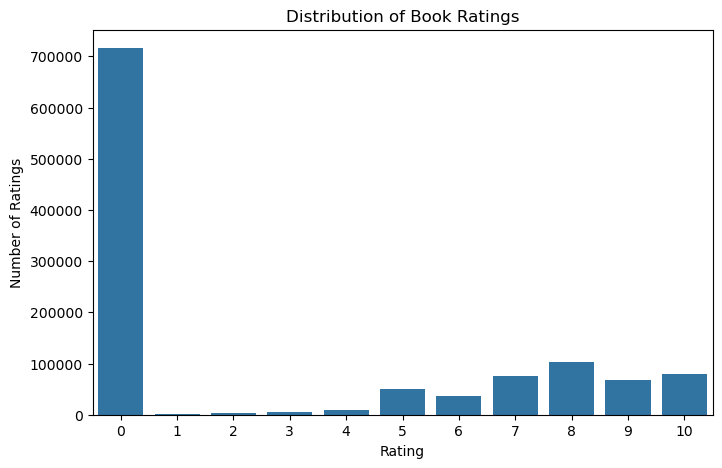

In [7]:
# Rating Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=ratings,
    x="Book-Rating"
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

Insight: 

The rating distribution shows that users provide ratings across the 1–10 scale, while rating 0 represents implicit interaction rather than an explicit preference score.

In [8]:
# Explicit vs Implicit Ratings

explicit_ratings = ratings[ratings["Book-Rating"] > 0]

implicit_ratings = ratings[ratings["Book-Rating"] == 0]

print("Explicit Ratings:", len(explicit_ratings))
print("Implicit Ratings:", len(implicit_ratings))

Explicit Ratings: 433671
Implicit Ratings: 716109


In [9]:
# Explicit Rating Statistics
print(explicit_ratings["Book-Rating"].describe())

count    433671.000000
mean          7.601066
std           1.843798
min           1.000000
25%           7.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: Book-Rating, dtype: float64


Insight:

Explicit ratings are generally concentrated toward the higher end of the scale, with a mean rating of approximately 7.60 and median of 8. This indicates that explicit feedback in the dataset is positively skewed toward higher ratings.

In [10]:
# Books EDA
# Most Rated Books
book_rating_counts = (
    ratings[ratings["Book-Rating"] > 0]
    .groupby("ISBN")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

book_rating_counts

ISBN
0316666343    707
0971880107    581
0385504209    487
0312195516    383
0679781587    333
0060928336    320
059035342X    313
0142001740    307
0446672211    295
044023722X    281
dtype: int64

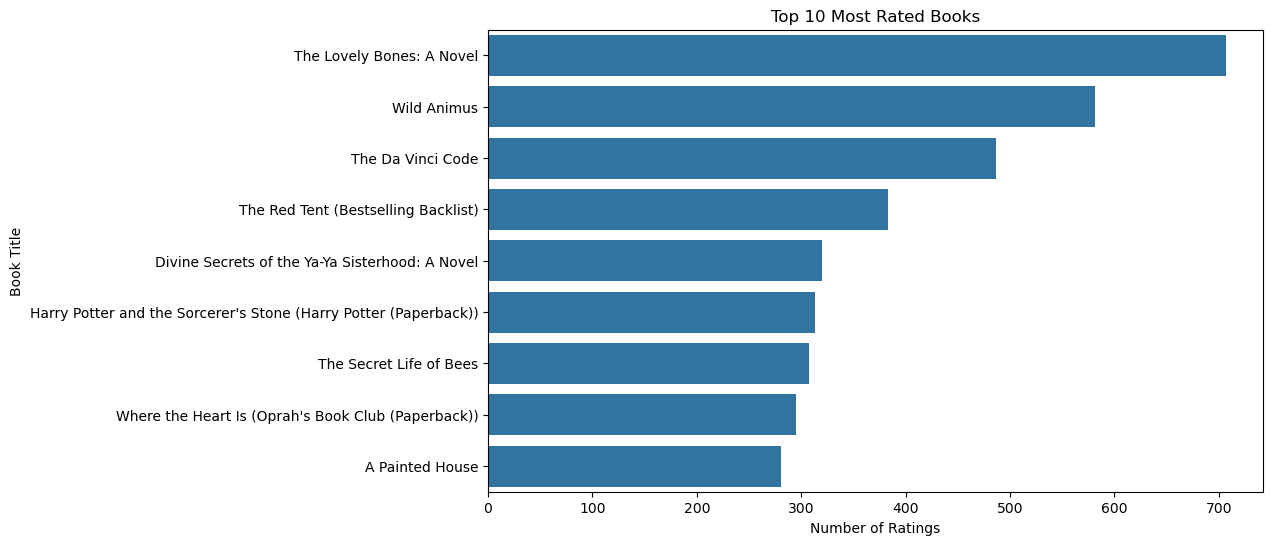

In [11]:
# Most Rated Books Visualization
top_books = book_rating_counts.reset_index()

top_books.columns = ["ISBN", "Rating_Count"]

top_books = top_books.merge(
    books[["ISBN", "Book-Title"]],
    on="ISBN",
    how="left"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_books,
    y="Book-Title",
    x="Rating_Count"
)

plt.title("Top 10 Most Rated Books")
plt.xlabel("Number of Ratings")
plt.ylabel("Book Title")
plt.show()

Insight:

A small number of books receive substantially more ratings than other books, indicating unequal popularity across the catalog. This supports the need for a popularity-based baseline and motivates personalized recommendation approaches.

In [12]:
# Most Active Users
user_rating_counts = (
    ratings.groupby("User-ID")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

user_rating_counts

User-ID
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
212898     4785
278418     4533
76352      3367
110973     3100
235105     3067
dtype: int64

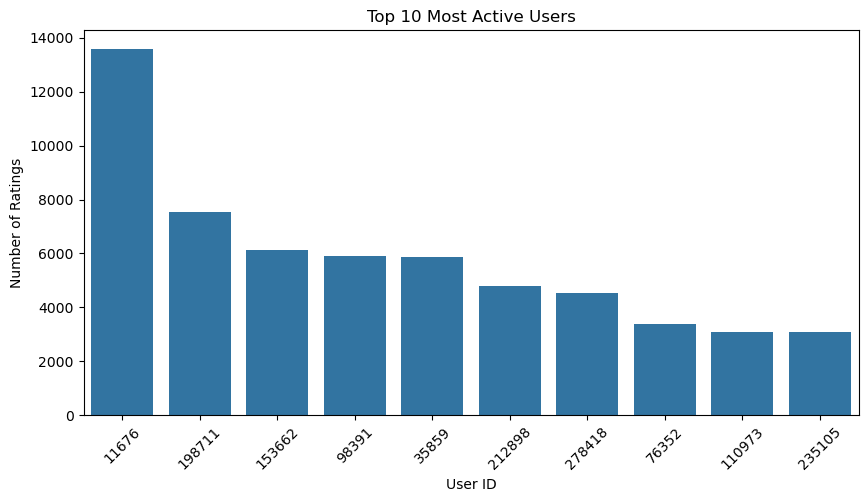

In [13]:
# Top 10 Most Active Users
plt.figure(figsize=(10,5))

sns.barplot(
    x=user_rating_counts.index.astype(str),
    y=user_rating_counts.values
)

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)

plt.show()


Insight: 

User activity varies considerably. A small number of users contribute a large number of ratings, while many users contribute fewer interactions. This variation is important when constructing collaborative-filtering models.

In [14]:
# Because the original dataset contains unrealistic ages, clean them:
users["Age"] = pd.to_numeric(
    users["Age"],
    errors="coerce"
)

users.loc[
    (users["Age"] < 5) | (users["Age"] > 100),
    "Age"
] = np.nan

users["Age"].fillna(
    users["Age"].median(),
    inplace=True
)

print(users["Age"].describe())

count    278858.000000
mean         33.643385
std          10.630979
min           5.000000
25%          29.000000
50%          32.000000
75%          35.000000
max         100.000000
Name: Age, dtype: float64


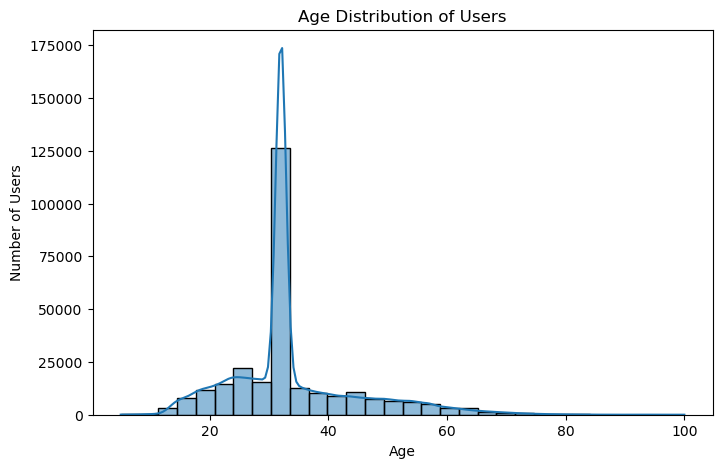

In [15]:
# Age Analysis
plt.figure(figsize=(8,5))

sns.histplot(
    users["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

Insight:

The age distribution shows that most users are concentrated between 20 and 60 years, with a significant peak around the early 30s. The distribution is right-skewed, with relatively fewer users above 60. The unusually high concentration at around 33 suggests a potential age-data quality issue that should be considered during preprocessing

In [16]:
# Top Authors
top_authors = (
    books["Book-Author"]
    .value_counts()
    .head(10)
)

display(top_authors)

Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64

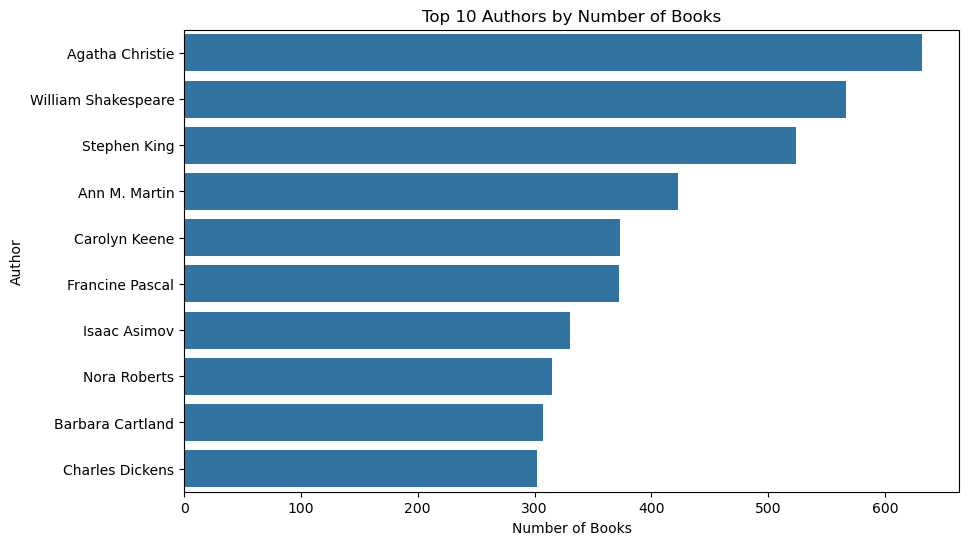

In [17]:
# Top 10 Authors by Number of Books
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_authors.values,
    y=top_authors.index
)

plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")

plt.show()

Insight:

A relatively small group of authors contributes a large number of books to the catalog, indicating that author information can be useful as a content feature for book similarity.

This connects directly to your TF-IDF model.

In [18]:
# Rating sparsity
# USER-BOOK MATRIX SPARSITY
num_users = ratings["User-ID"].nunique()
num_books = ratings["ISBN"].nunique()
num_ratings = len(ratings)

total_possible = num_users * num_books

sparsity = (
    1 - (num_ratings / total_possible)
) * 100

print("Number of Users:", num_users)
print("Number of Books:", num_books)
print("Number of Ratings:", num_ratings)
print(f"Sparsity: {sparsity:.4f}%")

Number of Users: 105283
Number of Books: 340556
Number of Ratings: 1149780
Sparsity: 99.9968%


Insight:

The user-book interaction matrix is extremely sparse because the number of observed ratings is very small compared with all possible user-book combinations. Therefore, sparse matrices and filtering are required for collaborative filtering.

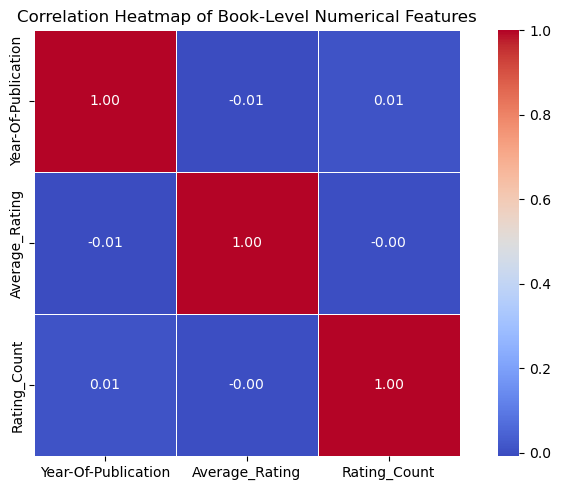

In [19]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

# ------------------------------------------------------------
# 1. Create book-level rating statistics
# ------------------------------------------------------------

book_rating_stats = (
    ratings
    .groupby("ISBN")["Book-Rating"]
    .agg(
        Average_Rating="mean",
        Rating_Count="count"
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Merge with Books dataset
# ------------------------------------------------------------

correlation_data = books[
    ["ISBN", "Year-Of-Publication"]
].merge(
    book_rating_stats,
    on="ISBN",
    how="inner"
)

# ------------------------------------------------------------
# 3. Convert numerical columns
# ------------------------------------------------------------

correlation_data["Year-Of-Publication"] = pd.to_numeric(
    correlation_data["Year-Of-Publication"],
    errors="coerce"
)

correlation_data["Average_Rating"] = pd.to_numeric(
    correlation_data["Average_Rating"],
    errors="coerce"
)

correlation_data["Rating_Count"] = pd.to_numeric(
    correlation_data["Rating_Count"],
    errors="coerce"
)

# ------------------------------------------------------------
# 4. Remove missing values
# ------------------------------------------------------------

correlation_data = correlation_data.dropna()

# ------------------------------------------------------------
# 5. Select numerical variables
# ------------------------------------------------------------

correlation_matrix = correlation_data[
    [
        "Year-Of-Publication",
        "Average_Rating",
        "Rating_Count"
    ]
].corr()

# ------------------------------------------------------------
# 6. Plot correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Book-Level Numerical Features")
plt.tight_layout()
plt.show()

Insight :

The correlation heatmap shows that there is almost no linear correlation among Year of Publication, Average Rating, and Rating Count. This indicates that the publication year does not strongly influence the average rating or the number of ratings received by a book.

## Key EDA Insights

* The dataset contains information about **books, users, and user ratings**, providing the required user-book interaction data for recommendation modeling.
* The rating distribution shows the pattern of user preferences across different rating values.
* The analysis highlights differences in user activity and book popularity.
* Missing values and duplicate records were identified and addressed during preprocessing.
* The EDA results helped determine the appropriate preprocessing and filtering steps for building the recommendation models.


# FEATURE ENGINEERING

In [20]:
# Clean Book Data
books_clean = books.copy()

# Remove duplicate ISBNs
books_clean = books_clean.drop_duplicates(
    subset="ISBN"
)

# Replace missing values
books_clean["Book-Title"] = books_clean["Book-Title"].fillna(
    "Unknown"
)

books_clean["Book-Author"] = books_clean["Book-Author"].fillna(
    "Unknown"
)

books_clean["Publisher"] = books_clean["Publisher"].fillna(
    "Unknown"
)

print("Books after cleaning:", books_clean.shape)

Books after cleaning: (271360, 8)


In [21]:
# Clean Ratings

ratings_clean = ratings.copy()

# Remove duplicate user-book combinations
ratings_clean = ratings_clean.drop_duplicates(
    subset=["User-ID", "ISBN"]
)

print(ratings_clean.shape)

(1149780, 3)


In [22]:
# Create Book-Level Features

book_features = (
    ratings_clean[ratings_clean["Book-Rating"] > 0]
    .groupby("ISBN")
    .agg(
        Average_Rating=("Book-Rating", "mean"),
        Rating_Count=("Book-Rating", "count")
    )
    .reset_index()
)

book_features.head()

,ISBN,Average_Rating,Rating_Count
0,0330299891,6.0,1
1,0375404120,3.0,1
2,9022906116,7.0,1
3,#6612432,5.0,1
4,'9607092910',10.0,1


In [23]:
# Merge Book Features

books_model = books_clean.merge(
    book_features,
    on="ISBN",
    how="left"
)

books_model["Average_Rating"] = (
    books_model["Average_Rating"]
    .fillna(0)
)

books_model["Rating_Count"] = (
    books_model["Rating_Count"]
    .fillna(0)
)

display(
    books_model[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Publisher",
            "Average_Rating",
            "Rating_Count"
        ]
    ].head()
)

,ISBN,Book-Title,Book-Author,Publisher,Average_Rating,Rating_Count
0,0195153448,Classical Mythology,Mark P. O. Morford,Oxford University Press,0.000000,0.0
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,7.666667,9.0
2,0060973129,Decision in Normandy,Carlo D'Este,HarperPerennial,7.500000,2.0
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,7.833333,6.0
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,0.000000,0.0


In [24]:
# Create Text Feature
# We can combine important book information:
# This feature will be used for Content-Based Recommendation.

books_model["Book_Text"] = (
    books_model["Book-Title"].astype(str)
    + " "
    + books_model["Book-Author"].astype(str)
    + " "
    + books_model["Publisher"].astype(str)
)

display(
    books_model[
        [
            "Book-Title",
            "Book-Author",
            "Publisher",
            "Book_Text"
        ]
    ].head()
)

,Book-Title,Book-Author,Publisher,Book_Text
0,Classical Mythology,Mark P. O. Morford,Oxford University Press,Classical Mythology Mark P. O. Morford Oxford ...
1,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,Clara Callan Richard Bruce Wright HarperFlamin...
2,Decision in Normandy,Carlo D'Este,HarperPerennial,Decision in Normandy Carlo D'Este HarperPerennial
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,Flu: The Story of the Great Influenza Pandemic...
4,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,The Mummies of Urumchi E. J. W. Barber W. W. N...


Explanation:

*Feature Engineering:* 

Book title, author, and publisher were combined into a single text feature for TF-IDF-based content similarity. Average rating and rating count were also generated as book-level statistical features.

In [25]:
# TRAIN/TEST SPLIT
# For recommendation evaluation, use explicit ratings only.
# Prepare Recommendation Dataset
recommendation_data = ratings_clean[
    ratings_clean["Book-Rating"] > 0
].copy()

print(
    "Explicit ratings:",
    recommendation_data.shape
)

Explicit ratings: (433671, 3)


In [26]:
# Train-Test Split
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(
    recommendation_data,
    test_size=0.20,
    random_state=42
)

print("Training data:", train_data.shape)
print("Testing data :", test_data.shape)

Training data: (346936, 3)
Testing data : (86735, 3)


Explanation :

Explicit ratings were used for recommendation evaluation because they represent direct user preferences. The data was divided into 80% training and 20% testing data to evaluate recommendation performance on unseen interactions.

# PHASE 2 — MODEL BUILDING AND MODEL EVALUATION

In [27]:
# MODEL 1 — POPULARITY-BASED RECOMMENDATION
# Build Popularity Model Using Training Data

popularity_model = (
    train_data
    .groupby("ISBN")
    .agg(
        Average_Rating=("Book-Rating", "mean"),
        Rating_Count=("Book-Rating", "count")
    )
    .reset_index()
)

In [28]:
# Filter Popular Books
popular_books = popularity_model[
    popularity_model["Rating_Count"] >= 5
].copy()

popular_books = popular_books.sort_values(
    by=["Average_Rating", "Rating_Count"],
    ascending=False
)

popular_books = popular_books.merge(
    books_model[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Publisher"
        ]
    ],
    on="ISBN",
    how="left"
)

display(
    popular_books[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Rating_Count"
        ]
    ].head(10)
)


,ISBN,Book-Title,Book-Author,Average_Rating,Rating_Count
0,1888054557,Postmarked Yesteryear: 30 Rare Holiday Postcards,Pamela E. Apkarian-Russell,10.0,10
1,0312099045,Route 66 Postcards: Greetings from the Mother ...,Michael Wallis,10.0,9
2,0394800893,The Sneetches and Other Stories,Dr. Seuss,10.0,7
3,0394831292,"Oh, the Thinks You Can Think! (I Can Read It A...",Dr. Seuss,10.0,6
4,0452262933,1984,George Orwell,10.0,6
5,0789254484,NaN,NaN,10.0,6
6,089471838X,Natural California: A Postcard Book,Not Applicable (Na ),10.0,6
7,0044409494,Hollywoodn't: A Queer Postcard Book,Laurence Jaugey-Paget,10.0,5
8,0198117477,William Shakespeare: The Complete Works,William Shakespeare,10.0,5
9,0373790651,"The Ultimate Seduction (Harlequin Blaze, No 61)",Janelle Denison,10.0,5


In [29]:
# Popularity Recommendation Function
def popularity_recommendations(n=10):
    
    return popular_books[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Rating_Count"
        ]
    ].head(n)

In [30]:
# Test:
popularity_recommendations(10)

,ISBN,Book-Title,Book-Author,Average_Rating,Rating_Count
0,1888054557,Postmarked Yesteryear: 30 Rare Holiday Postcards,Pamela E. Apkarian-Russell,10.0,10
1,0312099045,Route 66 Postcards: Greetings from the Mother ...,Michael Wallis,10.0,9
2,0394800893,The Sneetches and Other Stories,Dr. Seuss,10.0,7
3,0394831292,"Oh, the Thinks You Can Think! (I Can Read It A...",Dr. Seuss,10.0,6
4,0452262933,1984,George Orwell,10.0,6
5,0789254484,NaN,NaN,10.0,6
6,089471838X,Natural California: A Postcard Book,Not Applicable (Na ),10.0,6
7,0044409494,Hollywoodn't: A Queer Postcard Book,Laurence Jaugey-Paget,10.0,5
8,0198117477,William Shakespeare: The Complete Works,William Shakespeare,10.0,5
9,0373790651,"The Ultimate Seduction (Harlequin Blaze, No 61)",Janelle Denison,10.0,5


In [31]:
# MODEL 2 — CONTENT-BASED TF-IDF
# Do not calculate the complete 271,360 × 271,360 similarity matrix.
# Use only books with sufficient ratings.

# Prepare Content Dataset
# Create Book_Text
content_books = books_model.copy()

content_books["Book_Text"] = (
    content_books["Book-Title"].fillna("") + " " +
    content_books["Book-Author"].fillna("") + " " +
    content_books["Publisher"].fillna("")
)

print(content_books[["Book-Title", "Book-Author", "Publisher", "Book_Text"]].head())

                                          Book-Title           Book-Author  \
0                                Classical Mythology    Mark P. O. Morford   
1                                       Clara Callan  Richard Bruce Wright   
2                               Decision in Normandy          Carlo D'Este   
3  Flu: The Story of the Great Influenza Pandemic...      Gina Bari Kolata   
4                             The Mummies of Urumchi       E. J. W. Barber   

                    Publisher  \
0     Oxford University Press   
1       HarperFlamingo Canada   
2             HarperPerennial   
3        Farrar Straus Giroux   
4  W. W. Norton &amp; Company   

                                           Book_Text  
0  Classical Mythology Mark P. O. Morford Oxford ...  
1  Clara Callan Richard Bruce Wright HarperFlamin...  
2  Decision in Normandy Carlo D'Este HarperPerennial  
3  Flu: The Story of the Great Influenza Pandemic...  
4  The Mummies of Urumchi E. J. W. Barber W. W. N...  


In [32]:
# Check the column
print("Columns:")
print(content_books.columns.tolist())

Columns:
['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L', 'Average_Rating', 'Rating_Count', 'Book_Text']


In [33]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(
    content_books["Book_Text"]
)

print("TF-IDF Matrix:", tfidf_matrix.shape)

TF-IDF Matrix: (271360, 10000)


In [34]:
# calculate similarity only for the selected book:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def content_based_recommendations(book_title, n=10):

    # Find book
    matches = content_books[
        content_books["Book-Title"].str.lower() == book_title.lower()
    ]

    if matches.empty:
        return "Book not found."

    book_index = matches.index[0]

    # Get TF-IDF row position
    row_position = content_books.index.get_loc(book_index)

    # Calculate similarity only for selected book
    similarity_scores = cosine_similarity(
        tfidf_matrix[row_position],
        tfidf_matrix
    ).flatten()

    # Get top similar books
    similar_indices = np.argsort(similarity_scores)[::-1]

    # Remove selected book
    similar_indices = [
        i for i in similar_indices
        if i != row_position
    ][:n]

    recommendations = content_books.iloc[
        similar_indices
    ][[
        "Book-Title",
        "Book-Author",
        "Publisher"
    ]].copy()

    recommendations["Similarity"] = similarity_scores[
        similar_indices
    ]

    return recommendations

In [35]:
# Test :
sample_book = content_books["Book-Title"].iloc[0]

content_based_recommendations(
    sample_book,
    10
)

,Book-Title,Book-Author,Publisher,Similarity
205930,Who's Who in Classical Mythology (Who's Who Se...,Michael Grant,Oxford University Press,0.761318
193923,Classical mythology,Mark P. O Morford,Longman,0.735216
111977,Classical mythology,Mark P.O Morford,Longman,0.735216
95231,Classical Mythology,Mark P. O. Morford,John Wiley &amp; Sons,0.669770
54275,The Oxford Classical Dictionary,Simon Hornblower,Oxford University Press,0.629960
189495,The Oxford History of the Classical World,Oswyn Murray,Oxford University Press,0.586312
189499,The Oxford Companion to Classical Civilization,Simon Hornblower,Oxford University Press,0.562497
152608,Who's Who in Non-Classical Mythology,Egerston Sykes,Routledge,0.551861
107589,A Dictionary of World Mythology (Oxford Paperb...,Arthur Cottrell,Oxford University Press,0.543677
53103,Dictionary of Mythology: Mainly Classical,Bergen Evans,Laurel,0.538674


TF-IDF converts book title, author, and publisher information into numerical text features. Cosine similarity is then used to identify books with similar content characteristics.

In [36]:
# MODEL 3 — USER-BASED COLLABORATIVE FILTERING
# To prevent memory problems, use filtered explicit ratings.
# Filter Active Users and Books

cf_data = train_data.copy()

user_counts = (
    cf_data["User-ID"]
    .value_counts()
)

book_counts = (
    cf_data["ISBN"]
    .value_counts()
)

active_users = user_counts[
    user_counts >= 5
].index

popular_isbn = book_counts[
    book_counts >= 5
].index

cf_data = cf_data[
    cf_data["User-ID"].isin(active_users)
    &
    cf_data["ISBN"].isin(popular_isbn)
].copy()

print("CF data:", cf_data.shape)
print(
    "Users:",
    cf_data["User-ID"].nunique()
)

print(
    "Books:",
    cf_data["ISBN"].nunique()
)

CF data: (108534, 3)
Users: 10984
Books: 11288


In [37]:
# Create Sparse User-Book Matrix
from scipy.sparse import csr_matrix
user_codes = pd.Categorical(
    cf_data["User-ID"]
)

book_codes = pd.Categorical(
    cf_data["ISBN"]
)

user_index = user_codes.categories
book_index = book_codes.categories

user_book_sparse = csr_matrix(
    (
        cf_data["Book-Rating"].values,
        (
            user_codes.codes,
            book_codes.codes
        )
    ),
    shape=(
        len(user_index),
        len(book_index)
    )
)

print(
    "Sparse User-Book Matrix:",
    user_book_sparse.shape
)

Sparse User-Book Matrix: (10984, 11288)


In [38]:
# User Similarity
# Instead of converting the entire matrix to dense form:
user_similarity = cosine_similarity(
    user_book_sparse,
    dense_output=False
)

print(
    "User similarity matrix:",
    user_similarity.shape
)

User similarity matrix: (10984, 10984)


In [39]:
# User-Based Recommendation Function
def user_based_recommendations(
    user_id,
    n=10
):
    
    if user_id not in user_index:
        return pd.DataFrame(
            columns=[
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        )
    
    user_position = (
        user_index.get_loc(user_id)
    )
    
    similarity_scores = (
        user_similarity[user_position]
        .toarray()
        .flatten()
    )
    
    similar_users = np.argsort(
        similarity_scores
    )[::-1]
    
    # Remove current user
    similar_users = similar_users[
        similar_users != user_position
    ]
    
    similar_users = similar_users[:20]
    
    # Weighted recommendation scores
    scores = np.zeros(
        len(book_index)
    )
    
    for u in similar_users:
        
        similarity = (
            similarity_scores[u]
        )
        
        if similarity <= 0:
            continue
        
        user_ratings = (
            user_book_sparse[u]
            .toarray()
            .flatten()
        )
        
        scores += (
            similarity *
            user_ratings
        )
    
    # Exclude books already rated
    current_ratings = (
        user_book_sparse[user_position]
        .toarray()
        .flatten()
    )
    
    scores[current_ratings > 0] = -1
    
    top_books = np.argsort(
        scores
    )[::-1][:n]
    
    result = pd.DataFrame({
        "ISBN": book_index[top_books],
        "Score": scores[top_books]
    })
    
    result = result.merge(
        books_model[
            [
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        ],
        on="ISBN",
        how="left"
    )
    
    return result[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Score"
        ]
    ]

In [40]:
# MODEL 3 — USER-BASED COLLABORATIVE FILTERING
# Test Recommendation

sample_user = user_index[0]

print("Test User:", sample_user)

user_based_recommendations(
    sample_user,
    n=10
)

Test User: 8


,ISBN,Book-Title,Book-Author,Average_Rating,Score
0,0440212561,Outlander,DIANA GABALDON,8.580952,5.312532
1,0345459202,Big Stone Gap,Adriana Trigiani,8.057143,4.950516
2,0671510053,SHIPPING NEWS,Annie Proulx,7.733333,3.849599
3,0394281802,NaN,NaN,NaN,3.828445
4,038082101X,Daughter of Fortune: A Novel,Isabel Allende,7.396226,3.758209
5,0316601950,The Pilot's Wife : A Novel,Anita Shreve,7.503676,3.758209
6,1400034779,The No. 1 Ladies' Detective Agency (Today Show...,Alexander McCall Smith,8.049180,3.659207
7,0836218833,Attack Of The Deranged Mutant Killer Snow Goons,Bill Watterson,9.000000,3.659207
8,0316569321,White Oleander : A Novel,Janet Fitch,7.500000,3.499980
9,0771079516,NaN,NaN,NaN,3.288433


Filtering :

The original dataset is highly sparse and large. Users and books with fewer than five interactions were filtered to reduce computational complexity and improve the reliability of similarity calculations.

In [41]:
# MODEL 4 — ITEM-BASED COLLABORATIVE FILTERING
# Item-User Matrix
item_user_sparse = user_book_sparse.T.tocsr()

print(
    "Item-User Matrix:",
    item_user_sparse.shape
)

Item-User Matrix: (11288, 10984)


In [42]:
# Item Similarity
item_similarity = cosine_similarity(
    item_user_sparse,
    dense_output=False
)

print(
    "Item Similarity:",
    item_similarity.shape
)

Item Similarity: (11288, 11288)


In [43]:
# Item-Based Recommendation
def collaborative_recommendations(
    isbn,
    n=10
):
    
    if isbn not in book_index:
        return pd.DataFrame(
            columns=[
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        )
    
    item_position = (
        book_index.get_loc(isbn)
    )
    
    similarity_scores = (
        item_similarity[item_position]
        .toarray()
        .flatten()
    )
    
    similarity_scores[item_position] = -1
    
    top_indices = np.argsort(
        similarity_scores
    )[::-1][:n]
    
    recommended_isbn = (
        book_index[top_indices]
    )
    
    result = pd.DataFrame({
        "ISBN": recommended_isbn,
        "Similarity": similarity_scores[
            top_indices
        ]
    })
    
    result = result.merge(
        books_model[
            [
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        ],
        on="ISBN",
        how="left"
    )
    
    return result[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Similarity"
        ]
    ]

In [44]:
# Test:
sample_isbn = book_index[0]

collaborative_recommendations(
    sample_isbn,
    10
)

,ISBN,Book-Title,Book-Author,Average_Rating,Similarity
0,1844262553,Free,Paul Vincent,8.600000,0.419314
1,1561449164,Pound It (Popular Mechanics for Kids),unknown,8.800000,0.419314
2,0385326335,A Letter to Mrs. Roosevelt,C. COCO DE YOUNG,9.500000,0.419314
3,1550544683,Jade Peony,Wayson Choy,7.666667,0.419314
4,1410729435,Lucy's Treasure,G. E. Dabbs,9.600000,0.419314
5,3446202692,"Eine Frau, Eine Wohnung, Ein Roman",Wilhelm Genazino,7.100000,0.419314
6,3499230933,Adressat unbekannt.,Kathrine Kressmann Taylor,7.166667,0.419314
7,0972044205,The Breach,Brian Kaufman,8.571429,0.419314
8,0451408756,The Piper's Sons,Bruce Chandler Fergusson,6.333333,0.419314
9,8804342838,Due di due (Bestsellers),Andrea De Carlo,7.666667,0.419314


In [45]:
# MODEL 5 — SVD MATRIX FACTORIZATION
# Train SVD
from sklearn.decomposition import TruncatedSVD
n_components = 50

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

user_latent = svd.fit_transform(
    user_book_sparse
)

item_latent = svd.components_

print(
    "User latent shape:",
    user_latent.shape
)

print(
    "Item latent shape:",
    item_latent.shape
)

print(
    "Explained variance:",
    svd.explained_variance_ratio_.sum()
)

User latent shape: (10984, 50)
Item latent shape: (50, 11288)
Explained variance: 0.13462604566171152


Insight:

The 50 latent components explain approximately 13.46% of the variance in the sparse interaction matrix. SVD still provides useful latent representations for recommendation, but the relatively low explained variance indicates that the interaction data contains substantial complexity not captured by these 50 component

In [46]:
# SVD Recommendation
def svd_recommendations(
    user_id,
    n=10
):
    
    if user_id not in user_index:
        return pd.DataFrame(
            columns=[
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating",
                "Score"
            ]
        )
    
    user_position = (
        user_index.get_loc(user_id)
    )
    
    user_vector = user_latent[
        user_position
    ]
    
    scores = (
        user_vector @ item_latent
    )
    
    # Remove already rated books
    rated_books = (
        user_book_sparse[
            user_position
        ]
        .toarray()
        .flatten()
    )
    
    scores[rated_books > 0] = -1
    
    top_indices = np.argsort(
        scores
    )[::-1][:n]
    
    result = pd.DataFrame({
        "ISBN": book_index[top_indices],
        "Score": scores[top_indices]
    })
    
    result = result.merge(
        books_model[
            [
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        ],
        on="ISBN",
        how="left"
    )
    
    return result[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Score"
        ]
    ]

In [47]:
# MODEL 5 — SVD MATRIX FACTORIZATION
# Test Recommendation

sample_user = cf_data["User-ID"].iloc[0]

print("Test User:", sample_user)

recommendations = svd_recommendations(
    sample_user,
    n=10
)

display(recommendations)

Test User: 195079


,ISBN,Book-Title,Book-Author,Average_Rating,Score
0,0671027360,Angels &amp; Demons,Dan Brown,8.100372,0.674910
1,0345370775,Jurassic Park,Michael Crichton,7.850000,0.441567
2,0385484518,"Tuesdays with Morrie: An Old Man, a Young Man,...",MITCH ALBOM,8.615000,0.368930
3,0380002930,Watership Down,Richard Adams,8.620000,0.354756
4,0440206154,Red Dragon,Thomas Harris,7.957831,0.293468
5,0441172717,Dune (Remembering Tomorrow),Frank Herbert,8.973333,0.268225
6,0345342968,Fahrenheit 451,RAY BRADBURY,8.628049,0.255695
7,0446532231,"Dude, Where's My Country?",Michael Moore,8.337079,0.250341
8,0441003257,Good Omens,Neil Gaiman,8.195402,0.236216
9,0877017883,Griffin &amp; Sabine: An Extraordinary Corresp...,Nick Bantock,9.062500,0.234413


In [48]:
# MODEL 6 — HYBRID RECOMMENDATION
# Content-Based + Item-Based Collaborative Filtering
# Step 1: Prepare Content Data

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Copy book data
content_books = books_model.copy()

# Reset index
content_books = content_books.reset_index(drop=True)

# Fill missing values
content_books["Book-Title"] = (
    content_books["Book-Title"]
    .fillna("")
)

content_books["Book-Author"] = (
    content_books["Book-Author"]
    .fillna("")
)

content_books["Publisher"] = (
    content_books["Publisher"]
    .fillna("")
)

# Create combined text
content_books["content"] = (
    content_books["Book-Title"]
    + " "
    + content_books["Book-Author"]
    + " "
    + content_books["Publisher"]
)

print("Content books:", content_books.shape)

Content books: (271360, 12)


In [49]:
# Step 2: TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(
    content_books["content"]
)

print("TF-IDF Matrix:", tfidf_matrix.shape)

TF-IDF Matrix: (271360, 10000)


In [50]:
# Step 3: Create Content Index

content_indices = {}

for idx, title in enumerate(
    content_books["Book-Title"]
):
    
    if title not in content_indices:
        content_indices[title] = idx

print(
    "Number of unique book titles:",
    len(content_indices)
)

Number of unique book titles: 242135


In [51]:
#Test:
print(
    list(content_indices.keys())[:10]
)

['Classical Mythology', 'Clara Callan', 'Decision in Normandy', 'Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It', 'The Mummies of Urumchi', "The Kitchen God's Wife", "What If?: The World's Foremost Military Historians Imagine What Might Have Been", 'PLEADING GUILTY', 'Under the Black Flag: The Romance and the Reality of Life Among the Pirates', "Where You'll Find Me: And Other Stories"]


In [52]:
# Step 4: Prepare Item-Based Collaborative Filtering

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Use filtered CF data
item_cf_data = cf_data.copy()

# Create categorical codes
item_user_codes = pd.Categorical(
    item_cf_data["ISBN"]
)

item_user_ids = pd.Categorical(
    item_cf_data["User-ID"]
)

# Item index
item_index = item_user_codes.categories

# User index
cf_user_index = item_user_ids.categories

# Create sparse Item-User matrix
item_user_sparse = csr_matrix(
    (
        item_cf_data["Book-Rating"].values,
        (
            item_user_codes.codes,
            item_user_ids.codes
        )
    ),
    shape=(
        len(item_index),
        len(cf_user_index)
    )
)

print(
    "Item-User Sparse Matrix:",
    item_user_sparse.shape
)

Item-User Sparse Matrix: (11288, 10984)


In [53]:
# Step 5: Item Similarity

item_similarity = cosine_similarity(
    item_user_sparse,
    dense_output=False
)

print(
    "Item Similarity Matrix:",
    item_similarity.shape
)

Item Similarity Matrix: (11288, 11288)


In [54]:
# Step 6: ISBN Index

book_index = item_index

print(
    "Number of collaborative books:",
    len(book_index)
)

Number of collaborative books: 11288


In [55]:
# MODEL 6 — HYBRID RECOMMENDATION
# Content-Based + Item-Based Collaborative Filtering

def hybrid_recommendations(
    book_title,
    n=10,
    content_weight=0.5,
    collaborative_weight=0.5
):

    # --------------------------------
    # Check book
    # --------------------------------

    if book_title not in content_indices:

        print(
            "Book not found:",
            book_title
        )

        return pd.DataFrame(
            columns=[
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Publisher",
                "Average_Rating",
                "Hybrid_Score"
            ]
        )

    # --------------------------------
    # Content position
    # --------------------------------

    content_idx = content_indices[
        book_title
    ]

    # --------------------------------
    # Content similarity
    # --------------------------------
    
    content_scores = cosine_similarity(
        tfidf_matrix[content_idx],
        tfidf_matrix
    ).flatten()

    # --------------------------------
    # Selected ISBN
    # --------------------------------

    selected_isbn = content_books.iloc[
        content_idx
    ]["ISBN"]

    # --------------------------------
    # Collaborative similarity
    # --------------------------------

    collaborative_scores_aligned = (
        np.zeros(
            len(content_books)
        )
    )

    if selected_isbn in book_index:

        item_position = book_index.get_loc(
            selected_isbn
        )

        collaborative_scores = (
            item_similarity[
                item_position
            ]
            .toarray()
            .flatten()
        )

        # ISBN → similarity
        collaborative_map = dict(
            zip(
                book_index,
                collaborative_scores
            )
        )

        collaborative_scores_aligned = (
            content_books["ISBN"]
            .map(
                collaborative_map
            )
            .fillna(0)
            .to_numpy()
        )

    # --------------------------------
    # Remove selected book
    # --------------------------------

    content_scores[
        content_idx
    ] = -1

    collaborative_scores_aligned[
        content_idx
    ] = -1

    # --------------------------------
    # Normalize function
    # --------------------------------

    def normalize(scores):

        scores = np.asarray(
            scores,
            dtype=float
        )

        minimum = scores.min()
        maximum = scores.max()

        if maximum == minimum:

            return np.zeros_like(
                scores
            )

        return (
            scores - minimum
        ) / (
            maximum - minimum
        )

    # --------------------------------
    # Normalize scores
    # --------------------------------

    content_norm = normalize(
        content_scores
    )

    collaborative_norm = normalize(
        collaborative_scores_aligned
    )

    # --------------------------------
    # Hybrid score
    # --------------------------------

    hybrid_score = (
        content_weight
        * content_norm
        +
        collaborative_weight
        * collaborative_norm
    )

    # --------------------------------
    # Remove selected book again
    # --------------------------------

    hybrid_score[
        content_idx
    ] = -1

    # --------------------------------
    # Top N
    # --------------------------------

    top_indices = np.argsort(
        hybrid_score
    )[::-1][:n]

    # --------------------------------
    # Result
    # --------------------------------

    result = content_books.iloc[
        top_indices
    ][
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Publisher",
            "Average_Rating"
        ]
    ].copy()

    # Add hybrid score
    result["Hybrid_Score"] = (
        hybrid_score[
            top_indices
        ]
    )

    # Reset index
    result = result.reset_index(
        drop=True
    )

    return result

In [56]:
# MODEL 6 — TEST

sample_book = list(
    content_indices.keys()
)[0]

print(
    "Input Book:",
    sample_book
)

recommendations = (
    hybrid_recommendations(
        sample_book,
        n=10,
        content_weight=0.5,
        collaborative_weight=0.5
    )
)

display(
    recommendations
)

Input Book: Classical Mythology


,ISBN,Book-Title,Book-Author,Publisher,Average_Rating,Hybrid_Score
0,0195210301,Who's Who in Classical Mythology (Who's Who Se...,Michael Grant,Oxford University Press,0.0,1.000000
1,0801304652,Classical mythology,Mark P. O Morford,Longman,0.0,0.992590
2,0582280044,Classical mythology,Mark P.O Morford,Longman,9.0,0.992590
3,0801319536,Classical Mythology,Mark P. O. Morford,John Wiley &amp; Sons,7.0,0.974012
4,019866172X,The Oxford Classical Dictionary,Simon Hornblower,Oxford University Press,8.0,0.962710
5,0198721129,The Oxford History of the Classical World,Oswyn Murray,Oxford University Press,9.0,0.950320
6,0198601654,The Oxford Companion to Classical Civilization,Simon Hornblower,Oxford University Press,9.0,0.943559
7,0460861360,Who's Who in Non-Classical Mythology,Egerston Sykes,Routledge,8.0,0.940540
8,0192177478,A Dictionary of World Mythology (Oxford Paperb...,Arthur Cottrell,Oxford University Press,10.0,0.938216
9,0440208483,Dictionary of Mythology: Mainly Classical,Bergen Evans,Laurel,10.0,0.936796


# MODEL EVALUATION

In [57]:
# Step 1 — Define Relevant Test Ratings
# Use a rating threshold to define a relevant recommendation.
# Rating ≥ 7 → Relevant / liked book
# ============================================
# STEP 1 — DEFINE RELEVANT TEST ITEMS
# ============================================

RELEVANT_RATING = 7

test_relevant = (
    test_data[
        test_data["Book-Rating"] >= RELEVANT_RATING
    ]
    .groupby("User-ID")["ISBN"]
    .apply(set)
    .to_dict()
)

print("Number of users with relevant test books:",
      len(test_relevant))

Number of users with relevant test books: 23675


This means if a user rated a book 7 or higher in the test set, that book is considered a relevant item.

In [58]:
# Step 2 — Evaluation Functions
# We need one common evaluation function.
# ============================================
# STEP 2 — EVALUATION METRICS
# ============================================

def precision_at_k(recommended, relevant, k=10):
    
    recommended = recommended[:k]
    
    if len(recommended) == 0:
        return 0.0
    
    hits = len(set(recommended) & set(relevant))
    
    return hits / len(recommended)


def recall_at_k(recommended, relevant, k=10):
    
    if len(relevant) == 0:
        return 0.0
    
    recommended = recommended[:k]
    
    hits = len(set(recommended) & set(relevant))
    
    return hits / len(relevant)


def f1_at_k(precision, recall):
    
    if precision + recall == 0:
        return 0.0
    
    return (
        2 * precision * recall
        / (precision + recall)
    )


def hit_rate_at_k(recommended, relevant, k=10):
    
    recommended = recommended[:k]
    
    hits = len(
        set(recommended) & set(relevant)
    )
    
    return 1.0 if hits > 0 else 0.0

In [59]:
# Step 3 — Evaluation Helper
# This function evaluates any recommendation model.
# ============================================
# STEP 3 — GENERAL EVALUATION FUNCTION
# ============================================

def evaluate_model(
    recommendation_function,
    users,
    test_relevant,
    k=10
):
    
    precisions = []
    recalls = []
    f1_scores = []
    hit_rates = []
    
    evaluated_users = 0
    
    for user_id in users:
        
        # Skip users without relevant test items
        if user_id not in test_relevant:
            continue
        
        relevant_items = test_relevant[user_id]
        
        try:
            recommendations = recommendation_function(
                user_id,
                n=k
            )
            
            if recommendations is None:
                continue
            
            if isinstance(recommendations, str):
                continue
            
            if len(recommendations) == 0:
                continue
            
            # Get ISBN recommendations
            if "ISBN" not in recommendations.columns:
                continue
            
            recommended_items = (
                recommendations["ISBN"]
                .dropna()
                .tolist()
            )
            
            precision = precision_at_k(
                recommended_items,
                relevant_items,
                k
            )
            
            recall = recall_at_k(
                recommended_items,
                relevant_items,
                k
            )
            
            f1 = f1_at_k(
                precision,
                recall
            )
            
            hit = hit_rate_at_k(
                recommended_items,
                relevant_items,
                k
            )
            
            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1)
            hit_rates.append(hit)
            
            evaluated_users += 1
            
        except Exception:
            continue
    
    if evaluated_users == 0:
        return {
            "Precision@10": 0,
            "Recall@10": 0,
            "F1@10": 0,
            "Hit Rate@10": 0,
            "Users Evaluated": 0
        }
    
    return {
        "Precision@10": np.mean(precisions),
        "Recall@10": np.mean(recalls),
        "F1@10": np.mean(f1_scores),
        "Hit Rate@10": np.mean(hit_rates),
        "Users Evaluated": evaluated_users
    }

In [60]:
# MODEL 1 — POPULARITY EVALUATION

There is one important issue here:

popularity model does not require a user ID. It returns the same books for everyone.

So we create a wrapper.

In [61]:
# ============================================
# MODEL 1 — POPULARITY EVALUATION FUNCTION
# ============================================

def popularity_for_user(user_id, n=10):
    
    return popularity_recommendations(n)

In [62]:
# ============================================
# EVALUATE MODEL 1
# ============================================

evaluation_users = list(test_relevant.keys())

popularity_results = evaluate_model(
    popularity_for_user,
    evaluation_users,
    test_relevant,
    k=10
)

print("MODEL 1 — POPULARITY")
print(popularity_results)

MODEL 1 — POPULARITY
{'Precision@10': np.float64(5.0686378035902856e-05), 'Recall@10': np.float64(0.00013245412337281398), 'F1@10': np.float64(5.487155855255995e-05), 'Hit Rate@10': np.float64(0.0005068637803590286), 'Users Evaluated': 23675}


In [63]:
# MODEL 2 — CONTENT-BASED EVALUATION

Therefore, we need to evaluate it based on books that each test user rated positively.
First create a wrapper.

In [64]:
# ============================================
# MODEL 2 — CONTENT-BASED EVALUATION
# ============================================

def content_for_book(book_title, n=10):
    
    result = content_based_recommendations(
        book_title,
        n
    )
    
    if isinstance(result, str):
        return pd.DataFrame()
    
    return result

In [65]:
# ============================================
# CONTENT-BASED EVALUATION
# ============================================

def evaluate_content_model(
    test_data,
    test_relevant,
    k=10,
    max_users=1000
):
    
    precisions = []
    recalls = []
    f1_scores = []
    hit_rates = []
    
    users = list(test_relevant.keys())[:max_users]
    
    for user_id in users:
        
        relevant_books = test_relevant[user_id]
        
        if len(relevant_books) < 2:
            continue
        
        user_test_books = (
            test_data[
                test_data["User-ID"] == user_id
            ]["ISBN"]
            .tolist()
        )
        
        user_precision = []
        user_recall = []
        user_f1 = []
        user_hit = []
        
        for isbn in user_test_books:
            
            book_match = books_model[
                books_model["ISBN"] == isbn
            ]
            
            if book_match.empty:
                continue
            
            title = book_match.iloc[0]["Book-Title"]
            
            if pd.isna(title):
                continue
            
            try:
                recommendations = (
                    content_based_recommendations(
                        title,
                        k
                    )
                )
                
                if isinstance(
                    recommendations,
                    str
                ):
                    continue
                
                if recommendations.empty:
                    continue
                
                recommended_titles = (
                    recommendations["Book-Title"]
                    .dropna()
                    .tolist()
                )
                
                recommended_isbn = (
                    books_model[
                        books_model["Book-Title"]
                        .isin(recommended_titles)
                    ]["ISBN"]
                    .tolist()
                )
                
                # Exclude the input book
                relevant_for_eval = (
                    relevant_books - {isbn}
                )
                
                precision = precision_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                recall = recall_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                f1 = f1_at_k(
                    precision,
                    recall
                )
                
                hit = hit_rate_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                user_precision.append(precision)
                user_recall.append(recall)
                user_f1.append(f1)
                user_hit.append(hit)
                
            except Exception:
                continue
        
        if user_precision:
            precisions.append(np.mean(user_precision))
            recalls.append(np.mean(user_recall))
            f1_scores.append(np.mean(user_f1))
            hit_rates.append(np.mean(user_hit))
    
    return {
        "Precision@10": np.mean(precisions),
        "Recall@10": np.mean(recalls),
        "F1@10": np.mean(f1_scores),
        "Hit Rate@10": np.mean(hit_rates),
        "Users Evaluated": len(precisions)
    }

In [66]:
content_results = evaluate_content_model(
    test_data,
    test_relevant,
    k=10,
    max_users=1000
)

print("MODEL 2 — CONTENT-BASED")
print(content_results)

MODEL 2 — CONTENT-BASED
{'Precision@10': np.float64(0.003612768812178201), 'Recall@10': np.float64(0.013695407772107199), 'F1@10': np.float64(0.004756621340187144), 'Hit Rate@10': np.float64(0.03330266900392968), 'Users Evaluated': 319}


In [67]:
# MODEL 3 — USER-BASED COLLABORATIVE FILTERING

In [68]:
# ============================================
# MODEL 3 — USER-BASED CF
# ============================================

user_results = evaluate_model(
    user_based_recommendations,
    evaluation_users,
    test_relevant,
    k=10
)

print("MODEL 3 — USER-BASED COLLABORATIVE FILTERING")
print(user_results)

MODEL 3 — USER-BASED COLLABORATIVE FILTERING
{'Precision@10': np.float64(0.01309594226901692), 'Recall@10': np.float64(0.02926693688286587), 'F1@10': np.float64(0.014245359065853603), 'Hit Rate@10': np.float64(0.09748018454986396), 'Users Evaluated': 8453}


In [69]:
# MODEL 4 — ITEM-BASED COLLABORATIVE FILTERING

In [70]:
# ============================================
# MODEL 4 — ITEM-BASED CF EVALUATION
# ============================================

def evaluate_item_model(
    test_data,
    test_relevant,
    k=10,
    max_users=1000
):
    
    precisions = []
    recalls = []
    f1_scores = []
    hit_rates = []
    
    users = list(test_relevant.keys())[:max_users]
    
    for user_id in users:
        
        relevant_books = test_relevant[user_id]
        
        if len(relevant_books) < 2:
            continue
        
        user_books = (
            test_data[
                test_data["User-ID"] == user_id
            ]["ISBN"]
            .tolist()
        )
        
        user_precision = []
        user_recall = []
        user_f1 = []
        user_hit = []
        
        for isbn in user_books:
            
            if isbn not in book_index:
                continue
            
            try:
                recommendations = (
                    collaborative_recommendations(
                        isbn,
                        k
                    )
                )
                
                if recommendations.empty:
                    continue
                
                recommended_isbn = (
                    recommendations["ISBN"]
                    .dropna()
                    .tolist()
                )
                
                relevant_for_eval = (
                    relevant_books - {isbn}
                )
                
                precision = precision_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                recall = recall_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                f1 = f1_at_k(
                    precision,
                    recall
                )
                
                hit = hit_rate_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                user_precision.append(precision)
                user_recall.append(recall)
                user_f1.append(f1)
                user_hit.append(hit)
                
            except Exception:
                continue
        
        if user_precision:
            precisions.append(np.mean(user_precision))
            recalls.append(np.mean(user_recall))
            f1_scores.append(np.mean(user_f1))
            hit_rates.append(np.mean(user_hit))
    
    return {
        "Precision@10": np.mean(precisions),
        "Recall@10": np.mean(recalls),
        "F1@10": np.mean(f1_scores),
        "Hit Rate@10": np.mean(hit_rates),
        "Users Evaluated": len(precisions)
    }

In [71]:
item_results = evaluate_item_model(
    test_data,
    test_relevant,
    k=10,
    max_users=1000
)

print("MODEL 4 — ITEM-BASED COLLABORATIVE FILTERING")
print(item_results)

MODEL 4 — ITEM-BASED COLLABORATIVE FILTERING
{'Precision@10': np.float64(0.0014142502818818609), 'Recall@10': np.float64(0.005162073854906712), 'F1@10': np.float64(0.0016757079722145923), 'Hit Rate@10': np.float64(0.013304296191138295), 'Users Evaluated': 250}


In [72]:
# MODEL 5 — SVD EVALUATION

In [73]:
# ============================================
# MODEL 5 — SVD
# ============================================

svd_results = evaluate_model(
    svd_recommendations,
    evaluation_users,
    test_relevant,
    k=10
)

print("MODEL 5 — SVD")
print(svd_results)

MODEL 5 — SVD
{'Precision@10': np.float64(0.011510706258133208), 'Recall@10': np.float64(0.02657399693031207), 'F1@10': np.float64(0.012782713432911217), 'Hit Rate@10': np.float64(0.09192002839228676), 'Users Evaluated': 8453}


In [74]:
# MODEL 6 — HYBRID EVALUATION

In [75]:
# ============================================
# MODEL 6 — HYBRID EVALUATION
# ============================================

def evaluate_hybrid_model(
    test_data,
    test_relevant,
    k=10,
    max_users=1000
):
    
    precisions = []
    recalls = []
    f1_scores = []
    hit_rates = []
    
    users = list(test_relevant.keys())[:max_users]
    
    for user_id in users:
        
        relevant_books = test_relevant[user_id]
        
        if len(relevant_books) < 2:
            continue
        
        user_books = (
            test_data[
                test_data["User-ID"] == user_id
            ]["ISBN"]
            .tolist()
        )
        
        user_precision = []
        user_recall = []
        user_f1 = []
        user_hit = []
        
        for isbn in user_books:
            
            book_match = books_model[
                books_model["ISBN"] == isbn
            ]
            
            if book_match.empty:
                continue
            
            title = book_match.iloc[0]["Book-Title"]
            
            if pd.isna(title):
                continue
            
            if title not in content_indices:
                continue
            
            try:
                
                recommendations = (
                    hybrid_recommendations(
                        title,
                        n=k,
                        content_weight=0.5,
                        collaborative_weight=0.5
                    )
                )
                
                if recommendations.empty:
                    continue
                
                recommended_isbn = (
                    recommendations["ISBN"]
                    .dropna()
                    .tolist()
                )
                
                relevant_for_eval = (
                    relevant_books - {isbn}
                )
                
                precision = precision_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                recall = recall_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                f1 = f1_at_k(
                    precision,
                    recall
                )
                
                hit = hit_rate_at_k(
                    recommended_isbn,
                    relevant_for_eval,
                    k
                )
                
                user_precision.append(precision)
                user_recall.append(recall)
                user_f1.append(f1)
                user_hit.append(hit)
                
            except Exception:
                continue
        
        if user_precision:
            precisions.append(np.mean(user_precision))
            recalls.append(np.mean(user_recall))
            f1_scores.append(np.mean(user_f1))
            hit_rates.append(np.mean(user_hit))
    
    return {
        "Precision@10": np.mean(precisions),
        "Recall@10": np.mean(recalls),
        "F1@10": np.mean(f1_scores),
        "Hit Rate@10": np.mean(hit_rates),
        "Users Evaluated": len(precisions)
    }

In [76]:
hybrid_results = evaluate_hybrid_model(
    test_data,
    test_relevant,
    k=10,
    max_users=1000
)

print("MODEL 6 — HYBRID")
print(hybrid_results)

MODEL 6 — HYBRID
{'Precision@10': np.float64(0.0034899841055660787), 'Recall@10': np.float64(0.01195044160879147), 'F1@10': np.float64(0.004486706429302792), 'Hit Rate@10': np.float64(0.030421024672725932), 'Users Evaluated': 319}


In [77]:
# STEP 7 — FINAL COMPARISON TABLE

In [78]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

evaluation_results = pd.DataFrame([
    
    {
        "Model": "Popularity-Based",
        **popularity_results
    },
    
    {
        "Model": "Content-Based TF-IDF",
        **content_results
    },
    
    {
        "Model": "User-Based CF",
        **user_results
    },
    
    {
        "Model": "Item-Based CF",
        **item_results
    },
    
    {
        "Model": "SVD Matrix Factorization",
        **svd_results
    },
    
    {
        "Model": "Hybrid",
        **hybrid_results
    }
])

display(evaluation_results)

,Model,Precision@10,Recall@10,F1@10,Hit Rate@10,Users Evaluated
0,Popularity-Based,0.000051,0.000132,0.000055,0.000507,23675
1,Content-Based TF-IDF,0.003613,0.013695,0.004757,0.033303,319
2,User-Based CF,0.013096,0.029267,0.014245,0.097480,8453
3,Item-Based CF,0.001414,0.005162,0.001676,0.013304,250
4,SVD Matrix Factorization,0.011511,0.026574,0.012783,0.091920,8453
5,Hybrid,0.003490,0.011950,0.004487,0.030421,319


Evaluation Note:

The number of evaluated users differs across models because some recommendation methods operate only for users/books available in the filtered collaborative or content datasets. Therefore, metric values should be interpreted together with the corresponding evaluation population.

In [79]:
# STEP 8 — Visualization

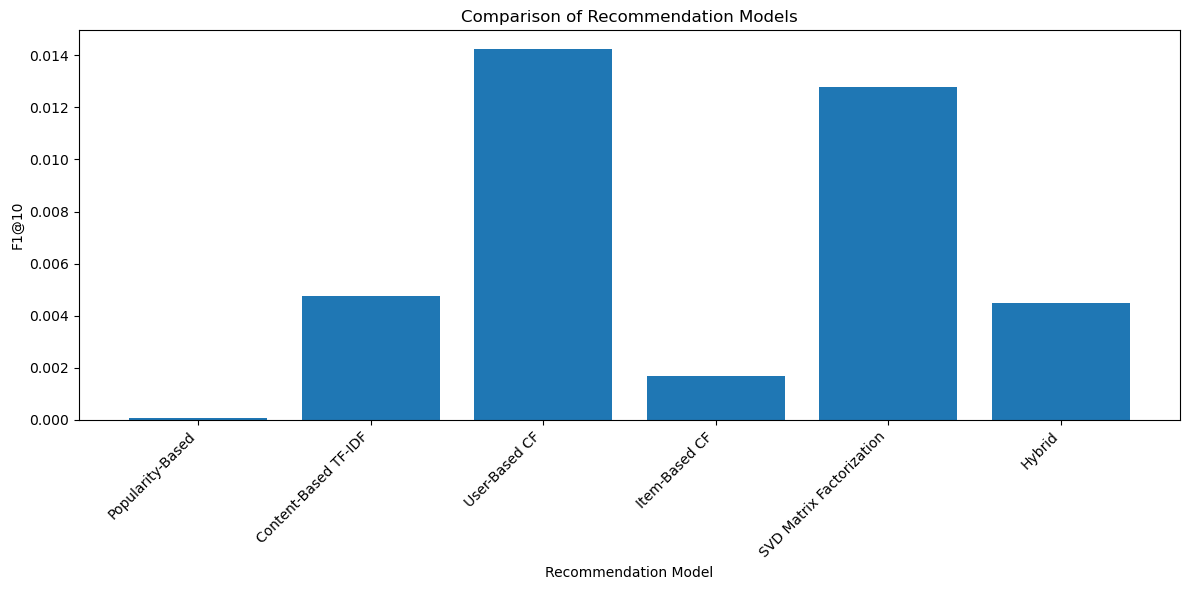

In [80]:
# ============================================
# MODEL COMPARISON — F1@10
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    evaluation_results["Model"],
    evaluation_results["F1@10"]
)

plt.xlabel("Recommendation Model")
plt.ylabel("F1@10")
plt.title("Comparison of Recommendation Models")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

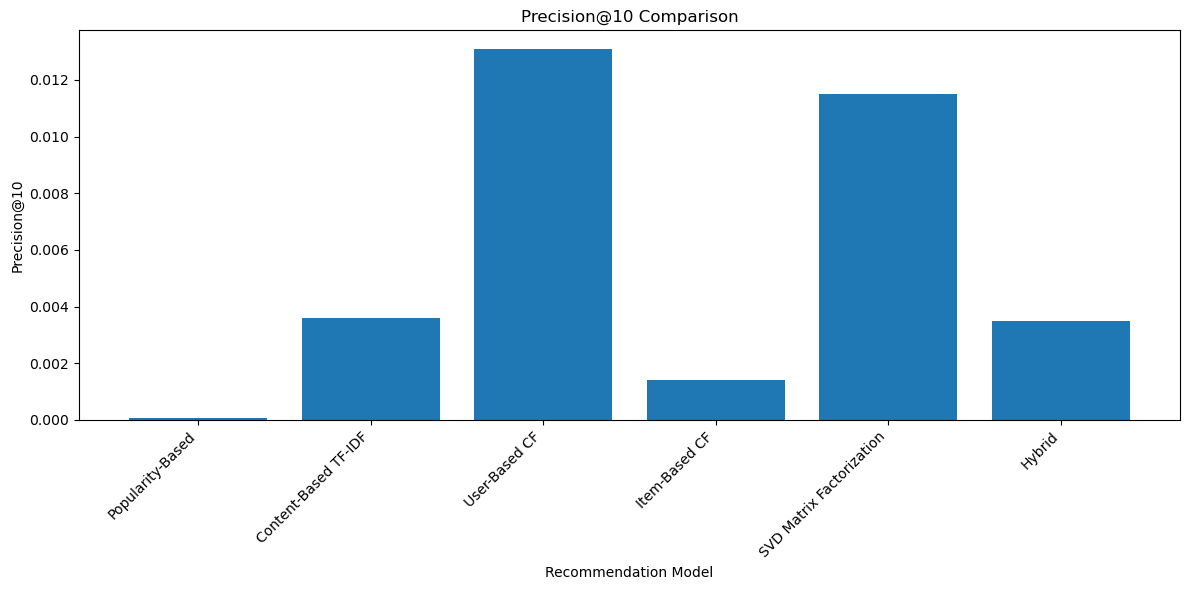

In [81]:
# ============================================
# MODEL COMPARISON — PRECISION@10
# ============================================

plt.figure(figsize=(12, 6))

plt.bar(
    evaluation_results["Model"],
    evaluation_results["Precision@10"]
)

plt.xlabel("Recommendation Model")
plt.ylabel("Precision@10")
plt.title("Precision@10 Comparison")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

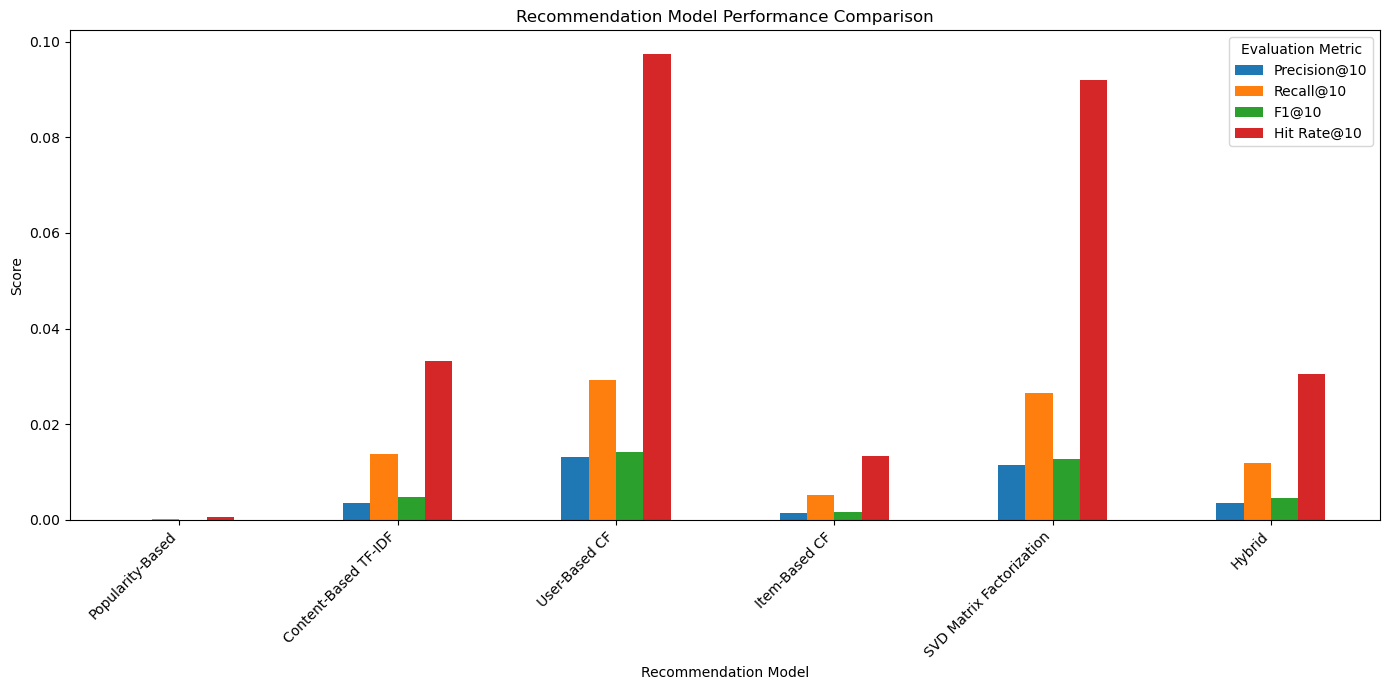

In [82]:
# =======================================
# 4-metric comparison chart
# =======================================

metrics = [
    "Precision@10",
    "Recall@10",
    "F1@10",
    "Hit Rate@10"
]

evaluation_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Recommendation Model Performance Comparison")
plt.xlabel("Recommendation Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

Insight:

User-Based Collaborative Filtering shows the highest observed Precision@10, Recall@10, F1@10, and Hit Rate@10 among the evaluated models. SVD is the next strongest approach on these metrics, while the popularity-based baseline performs substantially lower on this evaluation setup.

In [83]:
# STEP 9 — Save Evaluation Results

In [84]:
# ============================================
# SAVE RESULTS
# ============================================

evaluation_results.to_csv(
    "recommendation_model_evaluation.csv",
    index=False
)

print(
    "Evaluation results saved successfully."
)

Evaluation results saved successfully.


Model Evaluation & Selection:

Six recommendation approaches were evaluated using Precision@10, Recall@10, F1@10, and Hit Rate@10. Based on the obtained evaluation results, **User-Based Collaborative Filtering achieved the highest scores across all four metrics** and was selected as the final model for this experiment.

# Final Model Selection

In [85]:
# STEP 1 — Select the final model
final_model = "User-Based Collaborative Filtering"

print("Final Selected Model:", final_model)

Final Selected Model: User-Based Collaborative Filtering


In [86]:
# STEP 2 — Generate final recommendations

In [87]:
# Test it with a user:
sample_user = cf_data["User-ID"].iloc[0]

final_recommendations = user_based_recommendations(
    sample_user,
    n=10
)

print("User ID:", sample_user)

display(final_recommendations)

User ID: 195079


,ISBN,Book-Title,Book-Author,Average_Rating,Score
0,0446671223,The Celestine Prophecy : AN EXPERIENTIAL GUIDE,Carol Adrienne,6.285714,2.334054
1,0441569595,Neuromancer (Remembering Tomorrow),William Gibson,7.610390,2.035820
2,0451099648,Firestarter (Signet Book),Stephen King,7.450000,2.035820
3,0440204887,Illusions: The Adventures of a Reluctant Messiah,Richard Bach,8.444444,2.035820
4,0679750789,The Tightwad Gazette II: Promoting Thrift As a...,Amy Dacyczyn,7.900000,2.025479
5,0446532231,"Dude, Where's My Country?",Michael Moore,8.337079,2.025479
6,0425081818,The Talisman,Stephen King,7.500000,1.943852
7,0345339967,Foundation and Earth,Isaac Asimov,8.400000,1.937821
8,0451405498,Anna's Book,Ruth Rendell,8.285714,1.937298
9,0451203933,Black Hawk Down: A Story of Modern War,Mark Bowden,7.857143,1.937097


In [88]:
# STEP 3 — Analyze the recommendations

For User ID 195079, the User-Based Collaborative Filtering model generated 10 personalized book recommendations based on the preferences of similar users.

Key observations : 

* 10 books were recommended to the user.
* The Celestine Prophecy received the highest recommendation score (2.3341).
* Neuromancer, Firestarter, and Illusions also received strong scores (2.0358).
* Recommended books have average ratings ranging from approximately 6.29 to 8.44.
* Stephen King appears twice, suggesting that similar users showed interest in books by this author.
* Illusions has the highest average rating among the recommendations (8.44).
* The model recommends books that the target user has not already rated, based on your recommendation function.

In [89]:
# STEP 4 — Create final model summary

**Final Model — User-Based Collaborative Filtering**
The User-Based Collaborative Filtering model achieved the highest Precision@10, Recall@10, F1@10, and Hit Rate@10 among the evaluated models. It was therefore selected for generating personalized book recommendations

In [90]:
# ============================================
# SAVE USER-BASED CF MODEL
# ============================================

import pickle

with open("user_book_sparse.pkl", "wb") as file:
    pickle.dump(user_book_sparse, file)

with open("user_similarity.pkl", "wb") as file:
    pickle.dump(user_similarity, file)

with open("user_index.pkl", "wb") as file:
    pickle.dump(user_index, file)

with open("book_index.pkl", "wb") as file:
    pickle.dump(book_index, file)

books_model.to_pickle(
    "books_model.pkl"
)

print("User-Based CF model files saved successfully.")

User-Based CF model files saved successfully.


In [91]:
# Test loading the saved files

import pickle

with open("user_book_sparse.pkl", "rb") as file:
    user_book_sparse_loaded = pickle.load(file)

with open("user_similarity.pkl", "rb") as file:
    user_similarity_loaded = pickle.load(file)

with open("user_index.pkl", "rb") as file:
    user_index_loaded = pickle.load(file)

with open("book_index.pkl", "rb") as file:
    book_index_loaded = pickle.load(file)

books_model_loaded = pd.read_pickle("books_model.pkl")

print("Model files loaded successfully.")
print("Users:", len(user_index_loaded))
print("Books:", len(book_index_loaded))

Model files loaded successfully.
Users: 10984
Books: 11288


In [92]:
# create the final recommendation function

def final_recommendations(user_id, n=10):

    if user_id not in user_index_loaded:
        return pd.DataFrame(
            columns=[
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating",
                "Score"
            ]
        )

    user_position = user_index_loaded.get_loc(user_id)

    similarity_scores = (
        user_similarity_loaded[user_position]
        .toarray()
        .flatten()
    )

    similar_users = np.argsort(similarity_scores)[::-1]

    similar_users = similar_users[
        similar_users != user_position
    ][:20]

    scores = np.zeros(len(book_index_loaded))

    for u in similar_users:

        similarity = similarity_scores[u]

        if similarity <= 0:
            continue

        user_ratings = (
            user_book_sparse_loaded[u]
            .toarray()
            .flatten()
        )

        scores += similarity * user_ratings

    # Remove books already rated
    current_ratings = (
        user_book_sparse_loaded[user_position]
        .toarray()
        .flatten()
    )

    scores[current_ratings > 0] = -1

    top_books = np.argsort(scores)[::-1][:n]

    result = pd.DataFrame({
        "ISBN": book_index_loaded[top_books],
        "Score": scores[top_books]
    })

    result = result.merge(
        books_model_loaded[
            [
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        ],
        on="ISBN",
        how="left"
    )

    return result[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Score"
        ]
    ]

In [93]:
# Test final model

final_result = final_recommendations(195079, 10)

display(final_result)

,ISBN,Book-Title,Book-Author,Average_Rating,Score
0,0446671223,The Celestine Prophecy : AN EXPERIENTIAL GUIDE,Carol Adrienne,6.285714,2.334054
1,0441569595,Neuromancer (Remembering Tomorrow),William Gibson,7.610390,2.035820
2,0451099648,Firestarter (Signet Book),Stephen King,7.450000,2.035820
3,0440204887,Illusions: The Adventures of a Reluctant Messiah,Richard Bach,8.444444,2.035820
4,0679750789,The Tightwad Gazette II: Promoting Thrift As a...,Amy Dacyczyn,7.900000,2.025479
5,0446532231,"Dude, Where's My Country?",Michael Moore,8.337079,2.025479
6,0425081818,The Talisman,Stephen King,7.500000,1.943852
7,0345339967,Foundation and Earth,Isaac Asimov,8.400000,1.937821
8,0451405498,Anna's Book,Ruth Rendell,8.285714,1.937298
9,0451203933,Black Hawk Down: A Story of Modern War,Mark Bowden,7.857143,1.937097


# STREAMLIT DEPLOYMENT

In [94]:
# app.py

In [95]:
# ============================================================
# BOOK RECOMMENDATION SYSTEM
# User-Based Collaborative Filtering
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import pickle


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Book Recommendation System",
    page_icon="📚",
    layout="wide"
)


# ============================================================
# LOAD MODEL FILES
# ============================================================

@st.cache_resource
def load_model():

    with open("user_book_sparse.pkl", "rb") as file:
        user_book_sparse = pickle.load(file)

    with open("user_similarity.pkl", "rb") as file:
        user_similarity = pickle.load(file)

    with open("user_index.pkl", "rb") as file:
        user_index = pickle.load(file)

    with open("book_index.pkl", "rb") as file:
        book_index = pickle.load(file)

    books_model = pd.read_pickle("books_model.pkl")

    return (
        user_book_sparse,
        user_similarity,
        user_index,
        book_index,
        books_model
    )


# Load model artifacts
(
    user_book_sparse,
    user_similarity,
    user_index,
    book_index,
    books_model
) = load_model()


# ============================================================
# RECOMMENDATION FUNCTION
# ============================================================

def recommend_books(user_id, n=10):

    # Check whether user exists
    if user_id not in user_index:

        return pd.DataFrame(
            columns=[
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating",
                "Score"
            ]
        )

    # --------------------------------------------------------
    # Step 1: Get target user's position
    # --------------------------------------------------------

    user_position = user_index.get_loc(user_id)

    # --------------------------------------------------------
    # Step 2: Get similarity scores
    # --------------------------------------------------------

    similarity_scores = (
        user_similarity[user_position]
        .toarray()
        .flatten()
    )

    # --------------------------------------------------------
    # Step 3: Find similar users
    # --------------------------------------------------------

    similar_users = np.argsort(
        similarity_scores
    )[::-1]

    # Remove target user
    similar_users = similar_users[
        similar_users != user_position
    ]

    # Select top 20 similar users
    similar_users = similar_users[:20]

    # --------------------------------------------------------
    # Step 4: Calculate recommendation scores
    # --------------------------------------------------------

    scores = np.zeros(len(book_index))

    for u in similar_users:

        similarity = similarity_scores[u]

        # Ignore zero or negative similarity
        if similarity <= 0:
            continue

        user_ratings = (
            user_book_sparse[u]
            .toarray()
            .flatten()
        )

        scores += similarity * user_ratings

    # --------------------------------------------------------
    # Step 5: Remove books already rated by the user
    # --------------------------------------------------------

    current_ratings = (
        user_book_sparse[user_position]
        .toarray()
        .flatten()
    )

    scores[current_ratings > 0] = -1

    # --------------------------------------------------------
    # Step 6: Select Top-N books
    # --------------------------------------------------------

    top_books = np.argsort(
        scores
    )[::-1][:n]

    # --------------------------------------------------------
    # Step 7: Create recommendation result
    # --------------------------------------------------------

    result = pd.DataFrame({
        "ISBN": book_index[top_books],
        "Score": scores[top_books]
    })

    # --------------------------------------------------------
    # Step 8: Add book information
    # --------------------------------------------------------

    result = result.merge(
        books_model[
            [
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Average_Rating"
            ]
        ],
        on="ISBN",
        how="left"
    )

    # --------------------------------------------------------
    # Step 9: Return required columns
    # --------------------------------------------------------

    return result[
        [
            "ISBN",
            "Book-Title",
            "Book-Author",
            "Average_Rating",
            "Score"
        ]
    ]


# ============================================================
# STREAMLIT USER INTERFACE
# ============================================================

st.title("📚 Book Recommendation System")

st.write(
    "Get personalized book recommendations "
    "using User-Based Collaborative Filtering."
)


# ============================================================
# SIDEBAR - RECOMMENDATION SETTINGS
# ============================================================

st.sidebar.header("⚙️ Recommendation Settings")

user_id = st.sidebar.number_input(
    "Enter User ID",
    min_value=1,
    step=1,
    value=195079
)

number_of_books = st.sidebar.slider(
    "Number of Recommendations",
    min_value=5,
    max_value=20,
    value=10
)


# ============================================================
# RECOMMEND BUTTON
# ============================================================

if st.sidebar.button("📚 Get Recommendations"):

    recommendations = recommend_books(
        user_id,
        number_of_books
    )

    # --------------------------------------------------------
    # Invalid User
    # --------------------------------------------------------

    if recommendations.empty:

        st.error(
            "User ID not found in the trained model. "
            "Please enter a valid User ID."
        )

    # --------------------------------------------------------
    # Display Recommendations
    # --------------------------------------------------------

    else:

        st.success(
            f"Recommendations generated for User ID: {user_id}"
        )

        st.subheader("📖 Recommended Books")

        # Create display copy
        display_result = recommendations.copy()

        # Recommendation number
        display_result.index = range(
            1,
            len(display_result) + 1
        )

        # Rename columns for user-friendly display
        display_result.columns = [
            "ISBN",
            "Book Title",
            "Author",
            "Average Rating",
            "Recommendation Score"
        ]

        # Display recommendation table
        st.dataframe(
            display_result,
            use_container_width=True
        )


# ============================================================
# PROJECT INFORMATION
# ============================================================

st.sidebar.markdown("---")

st.sidebar.write(
    "**Model:** User-Based Collaborative Filtering"
)

st.sidebar.write(
    "**Recommendation Method:** Similar User Ratings"
)

st.sidebar.write(
    "**Recommendation Type:** Personalized Top-N Books"
)


# ============================================================
# FOOTER
# ============================================================

st.markdown("---")

st.caption(
    "Developed by PALSA MANOJ KUMAR | "
    "Book Recommendation System"
)

2026-09-24 21:16:05.333 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 21:16:05.338 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 21:16:05.882 
  command:

    streamlit run C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-24 21:16:05.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 21:16:05.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 21:16:06.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 21:16:06.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()

In [96]:
# Display the Absolute Path of app.py File
import os
print(os.path.abspath("app.py"))

C:\Users\PALSA MANOJ KUMAR\My Project 4\app.py


# requirements.txt
* streamlit
* pandas
* numpy
* scikit-learn
* matplotlib
* seaborn

## Conclusion

The Book Recommendation System was developed to provide personalized book recommendations using multiple recommendation techniques. Six models were implemented and evaluated using Precision@10, Recall@10, F1@10, and Hit Rate@10.

Based on the evaluation results, **User-Based Collaborative Filtering** was selected as the final model for personalized recommendations. The model identifies users with similar rating patterns and recommends books based on their preferences.

The final model was integrated into a **Streamlit application**, allowing users to enter their User ID and receive personalized book recommendations. The system demonstrates how collaborative filtering and machine learning techniques can be applied to build an interactive recommendation solution.
